<a href="https://colab.research.google.com/github/bhumika-ash/CFU_Counter/blob/main/CFU_Counter_w_YOLOv8s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### This notebook documents the ML pipeline for automated Colony Forming Unit(CFU) counting in petri dish images using YOLOv8s.The model has been trained on E.Coli petri dish images. Final model achieves mAP@50 of 0.812

##Install Libraries and Environment Setup

In [ ]:
!pip install ultralytics -q

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


##Mount Google Drive. <br>
All datasets, model checkpoints and results from other sessions are stored in google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_DIR = '/content/drive/MyDrive/CFU_Counter'
ROBOFLOW_DIR = f'{PROJECT_DIR}/dataset/roboflow'
AGAR_DIR = f'{PROJECT_DIR}/dataset/agar_ecoli'
config_path = f'{PROJECT_DIR}/dataset/combined_v2.yaml'

print(f"Project directory: {PROJECT_DIR}")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/CFU_Counter


## Datasets : <br>
Two datasets were used. The Roboflow dataset contains 112 annotated petri dish images. The AGAR dataset (E. coli subset) was filtered locally to retain only E. coli samples with bright and dark backgrounds and at least one annotated colony, yielding 1,843 images. <br>

Preprocessing was performed offline: annotation JSON files were parsed, bounding boxes converted to YOLOv8 format, and images copied to the structure expected by YOLOv8. The prepared dataset is stored in Google Drive.



In [ ]:
print("Dataset summary:")
for dataset, path in [("Roboflow", ROBOFLOW_DIR), ("AGAR E. coli", AGAR_DIR)]:
    print(f"\n{dataset}:")
    for split in ['train', 'val', 'test']:
        img_path = f'{path}/{split}/images'
        if os.path.exists(img_path):
            print(f"  {split}: {len(os.listdir(img_path))} images")
        else:
            print(f"  {split}: not found")

Dataset summary:

Roboflow:
  train: 25 images
  val: 57 images
  test: 30 images

AGAR E. coli:
  train: 1290 images
  val: 368 images
  test: 185 images


## Dataset Configuration <br>
A YAML configuration file defines the combined dataset paths and class labels for YOLOv8.

In [ ]:
import yaml

config = {
    'path': f'{PROJECT_DIR}/dataset',
    'train': [
        'roboflow/train/images',
        'agar_ecoli/train/images'
    ],
    'val': [
        'roboflow/val/images',
        'agar_ecoli/val/images'
    ],
    'test': 'agar_ecoli/test/images',
    'nc': 1,
    'names': ['colony']
}

with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("Dataset configuration saved.")
print(config)

Dataset configuration saved.
{'path': '/content/drive/MyDrive/CFU_Counter/dataset', 'train': ['roboflow/train/images', 'agar_ecoli/train/images'], 'val': ['roboflow/val/images', 'agar_ecoli/val/images'], 'test': 'agar_ecoli/test/images', 'nc': 1, 'names': ['colony']}


##Model Training <br>
YOLOv8s was trained at 1280px resolution on the combined dataset for 100 epochs. Higher resolution was chosen to preserve colony detail in high-resolution AGAR images. Augmentations include rotation (45 degrees), horizontal and vertical flips, and HSV color jitter.

In [ ]:
'''from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data=config_path,
    epochs=100,
    imgsz=1280,
    batch=8,
    patience=20,
    save=True,
    project=f'{PROJECT_DIR}/runs',
    name='cfu_combined_v2',
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.5,
    degrees=45,
)

print(f"Training complete. Best mAP50: {results.results_dict['metrics/mAP50(B)']:.3f}") '''

'from ultralytics import YOLO\n\nmodel = YOLO(\'yolov8s.pt\')\n\nresults = model.train(\n    data=config_path,\n    epochs=100,\n    imgsz=1280,\n    batch=8,\n    patience=20,\n    save=True,\n    project=f\'{PROJECT_DIR}/runs\',\n    name=\'cfu_combined_v2\',\n    hsv_h=0.015,\n    hsv_s=0.7,\n    hsv_v=0.4,\n    fliplr=0.5,\n    flipud=0.5,\n    degrees=45,\n)\n\nprint(f"Training complete. Best mAP50: {results.results_dict[\'metrics/mAP50(B)\']:.3f}") '

## Model Evaluation <br>
The best checkpoint is evaluated on the validation set.

In [ ]:
from ultralytics import YOLO

MODEL_PATH = f'{PROJECT_DIR}/runs/cfu_combined_v2/weights/best.pt'
model = YOLO(MODEL_PATH)

metrics = model.val(data=config_path)

print("Validation results:")
print(f"  mAP@50:     {metrics.box.map50:.3f}")
print(f"  mAP@50-95:  {metrics.box.map:.3f}")
print(f"  Precision:  {metrics.box.mp:.3f}")
print(f"  Recall:     {metrics.box.mr:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 3.0±1.4 MB/s, size: 1635.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/CFU_Counter/dataset/agar_ecoli/val/labels.cache... 425 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 425/425 63.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 3011, len(boxes) = 14988. To resolve this onl

##Training Curves

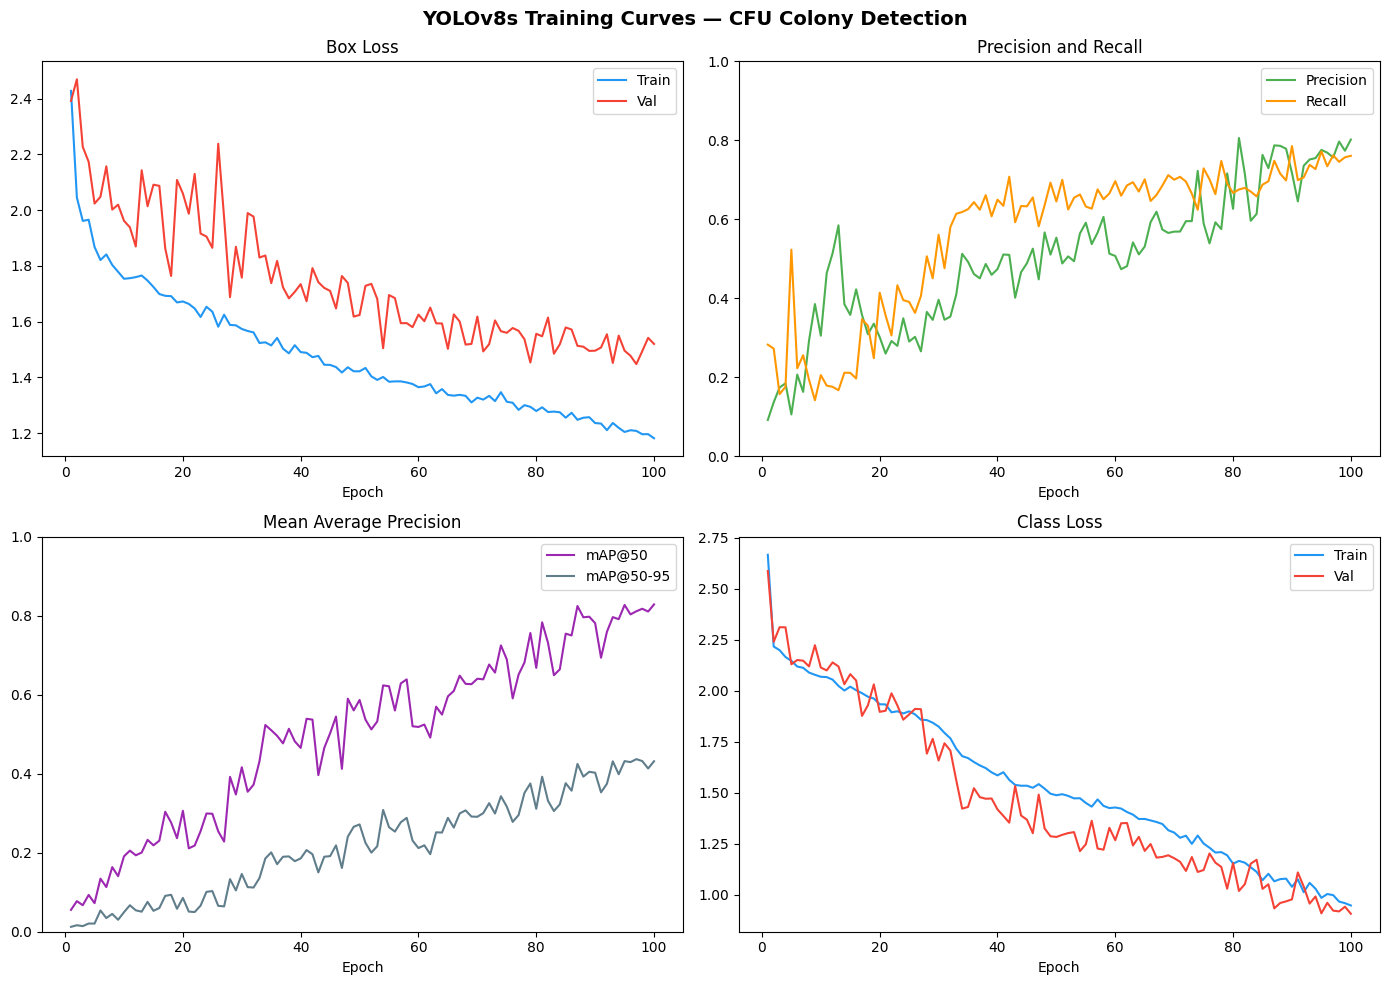

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{PROJECT_DIR}/runs/cfu_combined_v2/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('YOLOv8s Training Curves — CFU Colony Detection', fontsize=14, fontweight='bold')

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train', color='#2196F3')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='Val', color='#F44336')
axes[0,0].set_title('Box Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='#4CAF50')
axes[0,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='#FF9800')
axes[0,1].set_title('Precision and Recall')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylim(0, 1)
axes[0,1].legend()

axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#9C27B0')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#607D8B')
axes[1,0].set_title('Mean Average Precision')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylim(0, 1)
axes[1,0].legend()

axes[1,1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='#2196F3')
axes[1,1].plot(df['epoch'], df['val/cls_loss'], label='Val', color='#F44336')
axes[1,1].set_title('Class Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

##Inference on Test Image

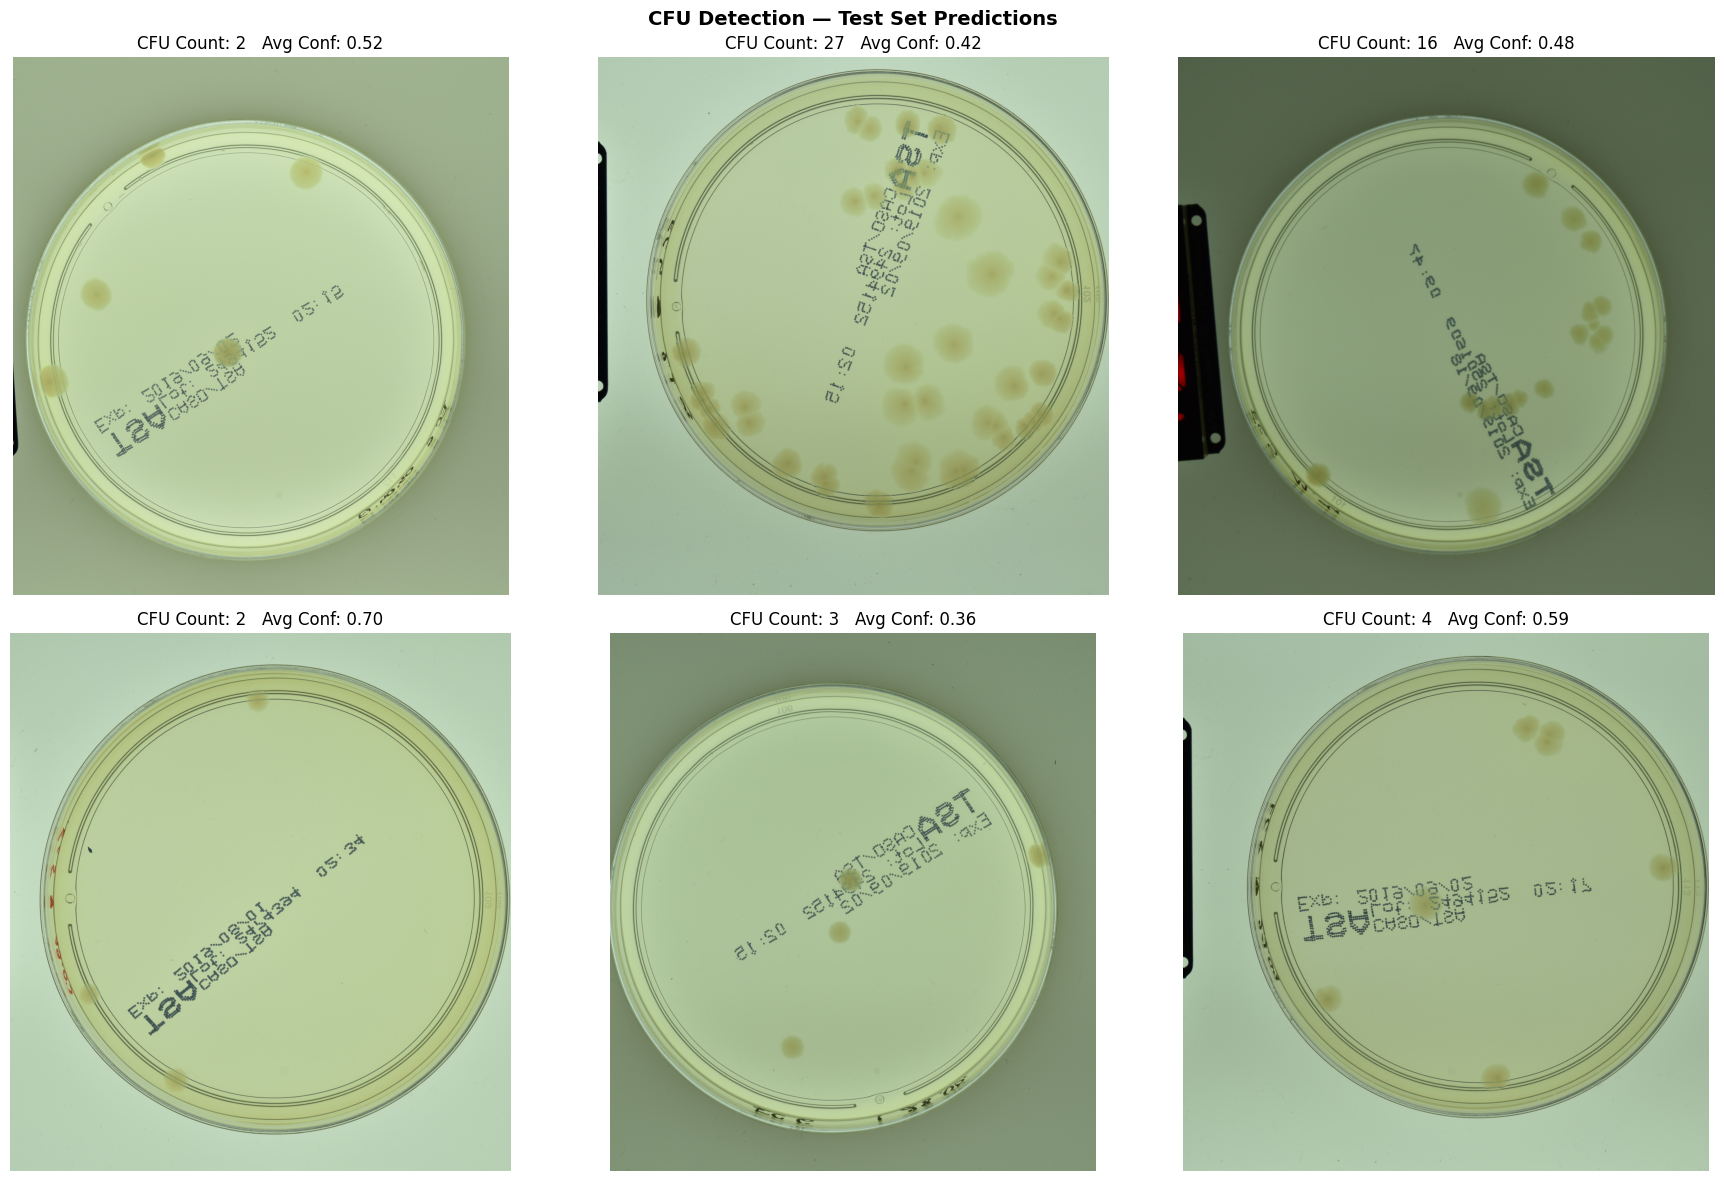

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

test_images = list(Path(f'{AGAR_DIR}/test/images').glob('*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('CFU Detection — Test Set Predictions', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), test_images):
    results = model(str(img_path), conf=0.30, imgsz=1280, verbose=False)
    boxes = results[0].boxes
    cfu_count = len(boxes)
    avg_conf = float(boxes.conf.mean()) if cfu_count > 0 else 0.0

    img = cv2.imread(str(img_path))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'CFU Count: {cfu_count}   Avg Conf: {avg_conf:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

##Inference on Lab Image

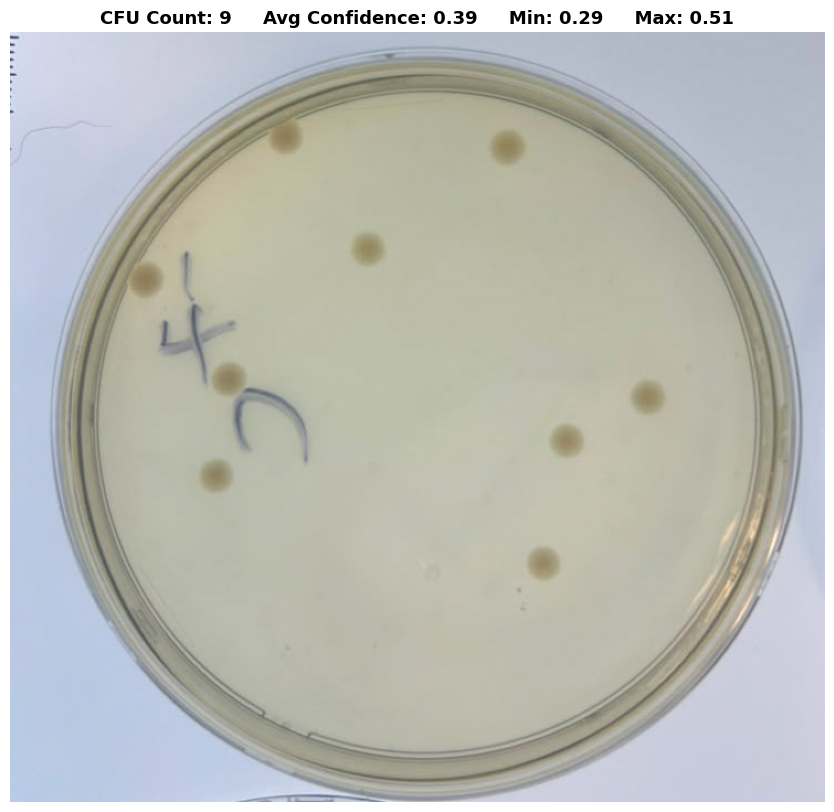

CFU Count:        9
Avg Confidence:   0.39
Min Confidence:   0.29
Max Confidence:   0.51


In [ ]:
img = cv2.imread('/content/drive/MyDrive/CFU_Counter/lab_img2_enhanced.jpeg')

results = model(img, conf=0.25, imgsz=1280, iou=0.3, verbose=False)

boxes = results[0].boxes
cfu_count = len(boxes)
avg_conf = float(boxes.conf.mean()) if cfu_count > 0 else 0.0
min_conf = float(boxes.conf.min()) if cfu_count > 0 else 0.0
max_conf = float(boxes.conf.max()) if cfu_count > 0 else 0.0

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(
    f'CFU Count: {cfu_count}     Avg Confidence: {avg_conf:.2f}     Min: {min_conf:.2f}     Max: {max_conf:.2f}',
    fontsize=13,
    fontweight='bold'
)
plt.axis('off')
plt.show()

print(f"CFU Count:        {cfu_count}")
print(f"Avg Confidence:   {avg_conf:.2f}")
print(f"Min Confidence:   {min_conf:.2f}")
print(f"Max Confidence:   {max_conf:.2f}")